In [1]:
import sys
!{sys.executable} -m pip install -e ../wfcrl-env #Use the notebooks Python & run pip from that python
#Forces pip to run inside same python env as notebook kernel

Obtaining file:///Users/kevinbabashov/Documents/Spring_2026/CSCI_5980/weather-vein/wfcrl-env
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Cloning https://github.com/cibeah/openfast_toolbox to /private/var/folders/zr/vfkt6hqx4vl7hmnlbxptt2x80000gn/T/pip-install-dq_bacjy/openfast-toolbox_096a2a479b9c4914b71ed47aa4418b49
  Running command git clone --filter=blob:none --quiet https://github.com/cibeah/openfast_toolbox /private/var/folders/zr/vfkt6hqx4vl7hmnlbxptt2x80000gn/T/pip-install-dq_bacjy/openfast-toolbox_096a2a479b9c4914b71ed47aa4418b49
  Resolved https://github.com/cibeah/openfast_toolbox to commit d2eb063e3fcf00a3c50e952248e355b0f19be588
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Building editable for WFCRL (pyproject.toml) ..

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wfcrl.rewards import StepPercentage
from wfcrl import environments as envs

sns.set_theme(style="whitegrid")



In [3]:
from wfcrl import environments as envs
envs.list_envs()

['Turb_TCRWP_Fastfarm',
 'Turb_TCRWP_Floris',
 'Turb3_Row1_Fastfarm',
 'Turb3_Row1_Floris',
 'Turb6_Row2_Fastfarm',
 'Turb6_Row2_Floris',
 'Turb16_Row5_Fastfarm',
 'Turb16_Row5_Floris',
 'Turb32_Row5_Fastfarm',
 'Turb32_Row5_Floris',
 'Ablaincourt_Fastfarm',
 'Ablaincourt_Floris',
 'HornsRev1_Fastfarm',
 'HornsRev1_Floris',
 'HornsRev2_Fastfarm',
 'HornsRev2_Floris',
 'Ormonde_Fastfarm',
 'Ormonde_Floris',
 'WMR_Fastfarm',
 'WMR_Floris',
 'Turb1_Row1_Fastfarm',
 'Turb1_Row1_Floris',
 'Turb2_Row1_Fastfarm',
 'Turb2_Row1_Floris',
 'Turb3_Row1_Fastfarm',
 'Turb3_Row1_Floris',
 'Turb4_Row1_Fastfarm',
 'Turb4_Row1_Floris',
 'Turb5_Row1_Fastfarm',
 'Turb5_Row1_Floris',
 'Turb6_Row1_Fastfarm',
 'Turb6_Row1_Floris',
 'Turb7_Row1_Fastfarm',
 'Turb7_Row1_Floris',
 'Turb8_Row1_Fastfarm',
 'Turb8_Row1_Floris',
 'Turb9_Row1_Fastfarm',
 'Turb9_Row1_Floris',
 'Turb10_Row1_Fastfarm',
 'Turb10_Row1_Floris',
 'Turb11_Row1_Fastfarm',
 'Turb11_Row1_Floris',
 'Turb12_Row1_Fastfarm',
 'Turb12_Row1_Floris',


In [4]:
from wfcrl import environments as envs
env = envs.make("Ablaincourt_Floris")


In [5]:
print(env.num_turbines)
print(env.action_space)
print(env.observation_space)

7
Dict('yaw': Box(-5.0, 5.0, (7,), float32))
Dict('yaw': Box(-40.0, 40.0, (7,), float32), 'freewind_measurements': Box([3. 0.], [ 28. 360.], (2,), float32), 'wind_speed': Box(3.0, 28.0, (7,), float32), 'wind_direction': Box(0.0, 360.0, (7,), float32))


In [6]:
def step_policy(i):
    n = env.num_turbines
    idx = np.arange(n, dtype=np.float32)

    downstream_bias = -1.0 * (idx / max(n - 1, 1))

    amp = 4.0
    period = 20.0
    direction = 1.0 if (i // 10) % 2 == 0 else -1.0
    phase = direction * (2.0 * np.pi * (i % period) / period)

    base = amp * np.sin(phase + (2.0 * np.pi * idx / max(n, 1)))

    probe = np.zeros(n, dtype=np.float32)
    if i % 15 == 0:
        probe[(i // 15) % n] = np.random.choice([-5.0, 5.0])

    jitter = np.random.normal(0.0, 0.5, size=n).astype(np.float32)

    yaw = np.clip(base + downstream_bias + probe + jitter, -5.0, 5.0).astype(np.float32)
    return {"yaw": yaw}


In [7]:
observation = env.reset()
r, i = 0, 0
done = False
while not done:
    joint_action = step_policy(i)
    observation, reward, termination, truncation, info = env.step(joint_action)
    r += reward
    i += 1
    done = termination or truncation
print(f"Total reward = {r}")

Total reward = [1016.56993819]


In [8]:
columns = [f"T{i+1}" for i in range(env.num_turbines)]
yaws = pd.DataFrame(np.c_[[h["yaw"] for h in env.history["observation"]]], columns=columns)
powers = pd.DataFrame(np.c_[[h for h in env.history["power"]]], columns=columns)
yaws

,T1,T2,T3,T4,T5,T6,T7
0,-4.879264,3.677620,3.535077,0.917223,-2.786679,-3.995476,-3.845303
1,-4.879264,3.677620,6.653634,0.280101,-7.121594,-3.995476,-3.845303
2,-2.939737,7.068388,6.653634,-1.164070,-7.121594,-8.995476,-5.929625
3,0.130287,10.331963,6.555948,-4.401702,-11.089184,-8.995476,-6.516922
4,0.130287,10.331963,6.689386,-7.734671,-11.089184,-11.588852,-5.283026
...,...,...,...,...,...,...,...
494,40.000000,30.806458,-40.000000,-40.000000,-40.000000,-29.242435,40.000000
495,40.000000,32.904892,-40.000000,-40.000000,-40.000000,-34.242435,40.000000
496,40.000000,36.253113,-39.411472,-40.000000,-40.000000,-37.277962,40.000000
497,40.000000,40.000000,-37.436367,-40.000000,-40.000000,-37.277962,38.895153


[Text(0, 0.5, 'Power (MW)'), Text(0.5, 0, 'Iterations')]

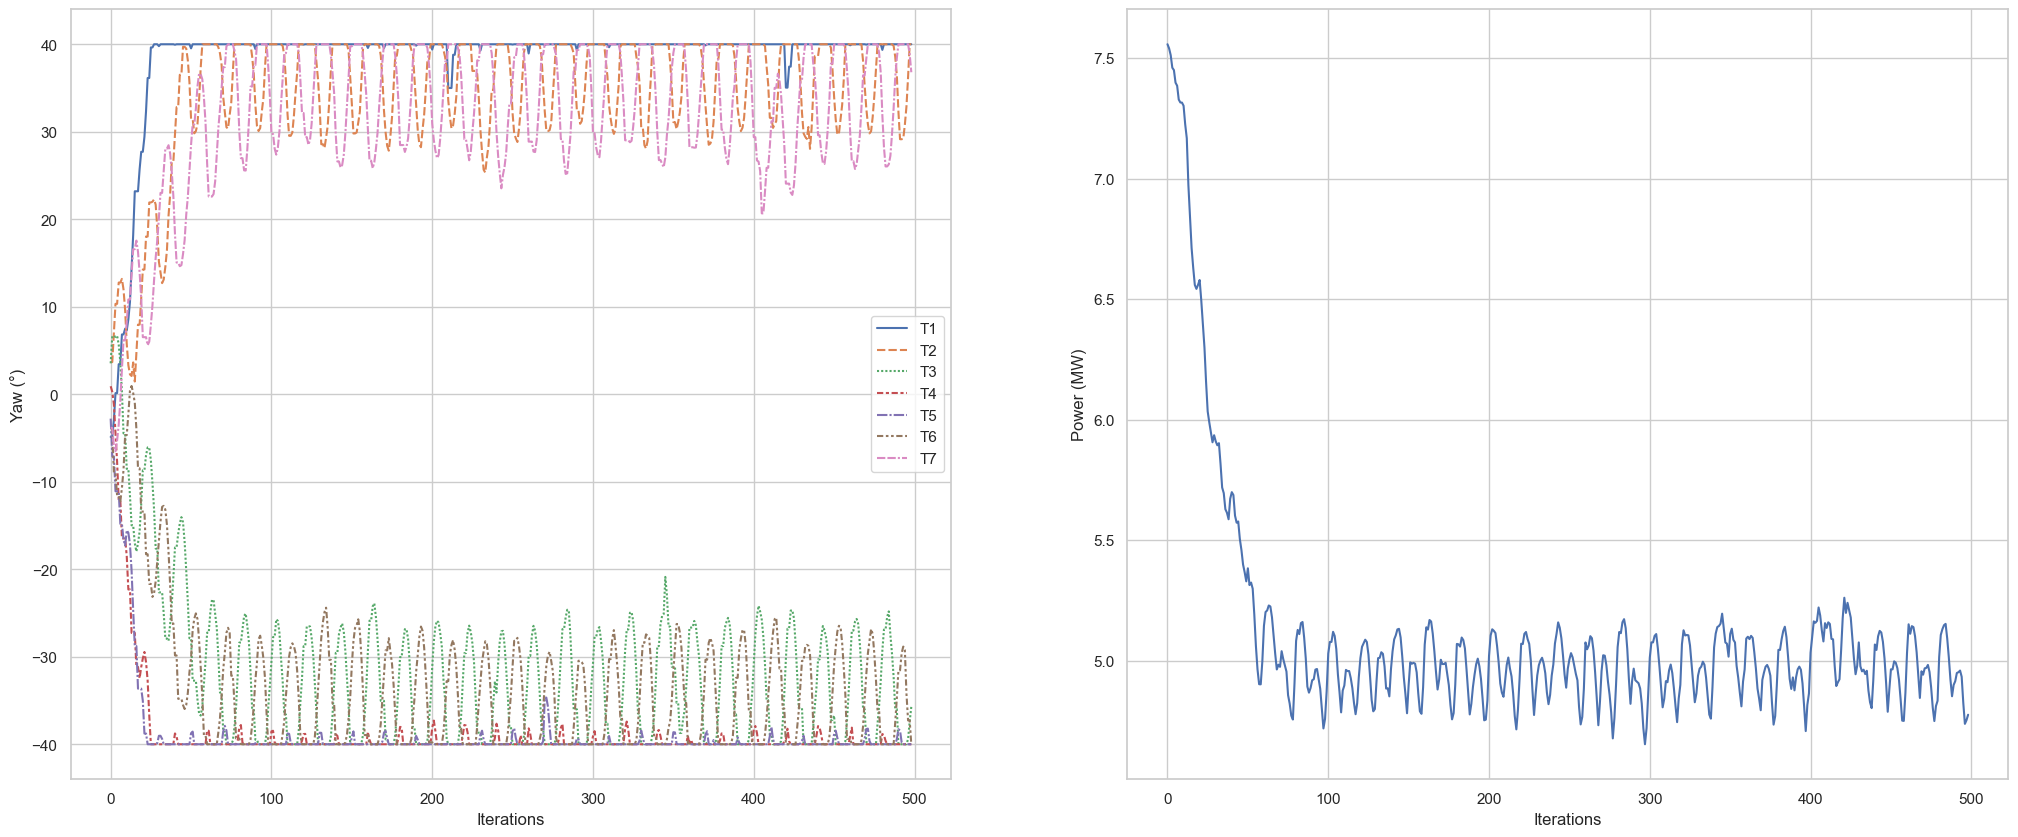

In [9]:
fig, ax = plt.subplots(ncols=2, figsize=(25, 10))
ax0 = sns.lineplot(yaws, ax=ax[0])
ax1 = sns.lineplot(powers.sum(1), ax=ax[1])
ax0.set(ylabel="Yaw (°)", xlabel="Iterations")
ax1.set(ylabel="Power (MW)", xlabel="Iterations")